In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prajwalbhamere/car-damage-severity-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-damage-severity-dataset' dataset.
Path to dataset files: /kaggle/input/car-damage-severity-dataset


In [2]:
!ls /kaggle/input/car-damage-severity-dataset/data3a

training  validation


In [3]:
import shutil
import os

source = os.path.join(path, "data3a")
destination = "/content/data3a"

# Remove existing copy if it exists
if os.path.exists(destination):
    shutil.rmtree(destination)

shutil.copytree(source, destination)

print("Dataset copied successfully!")

Dataset copied successfully!


In [4]:
!ls /content/data3a

training  validation


In [5]:
# ==============================
# Import Required Libraries
# ==============================

import os
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

#Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

# Torchvision
from torchvision import datasets, transforms, models

#Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")


In [6]:
DATASET_ROOT = "/content/data3a"
TRAIN_DIR = os.path.join(DATASET_ROOT,"training")
VAL_DIR = os.path.join(DATASET_ROOT, "validation")

# Training Configuration
IMAGE_SIZE = 224,
BATCH_SIZE = 32,
NUM_CLASSES = 3

epochs = 50

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)
print("Training Directory :", TRAIN_DIR)
print("Validation Directory :", VAL_DIR)

Device : cuda
Training Directory : /content/data3a/training
Validation Directory : /content/data3a/validation


In [7]:
train_dataset = datasets.ImageFolder(TRAIN_DIR)

val_dataset = datasets.ImageFolder(VAL_DIR)

print("Training Images:", len(train_dataset))

print("\nClasses")

print(train_dataset.classes)

print("\nClass Mapping")

print(train_dataset.class_to_idx)

Training Images: 1383

Classes
['01-minor', '02-moderate', '03-severe']

Class Mapping
{'01-minor': 0, '02-moderate': 1, '03-severe': 2}


In [8]:
# ============================================
# Inspect Dataset
# ============================================

image, label = train_dataset[0]

print("Image Type :", type(image))

print("Image Size :", image.size)

print("Label :", label)

print("Class :", train_dataset.classes[label])

Image Type : <class 'PIL.Image.Image'>
Image Size : (233, 217)
Label : 0
Class : 01-minor


In [9]:
# ============================================
# Dataset Summary
# ============================================

from collections import Counter

# Count images in each class
train_counts = Counter([label for _, label in train_dataset])
val_counts = Counter([label for _, label in val_dataset])

print("=" * 50)
print("TRAINING DATASET")
print("=" * 50)

for idx, class_name in enumerate(train_dataset.classes):
    print(f"{class_name:15s}: {train_counts[idx]} images")

print(f"\nTotal Training Images: {len(train_dataset)}")

print("\n" + "=" * 50)
print("VALIDATION DATASET")
print("=" * 50)

for idx, class_name in enumerate(val_dataset.classes):
    print(f"{class_name:15s}: {val_counts[idx]} images")

print(f"\nTotal Validation Images: {len(val_dataset)}")

TRAINING DATASET
01-minor       : 452 images
02-moderate    : 463 images
03-severe      : 468 images

Total Training Images: 1383

VALIDATION DATASET
01-minor       : 82 images
02-moderate    : 75 images
03-severe      : 91 images

Total Validation Images: 248


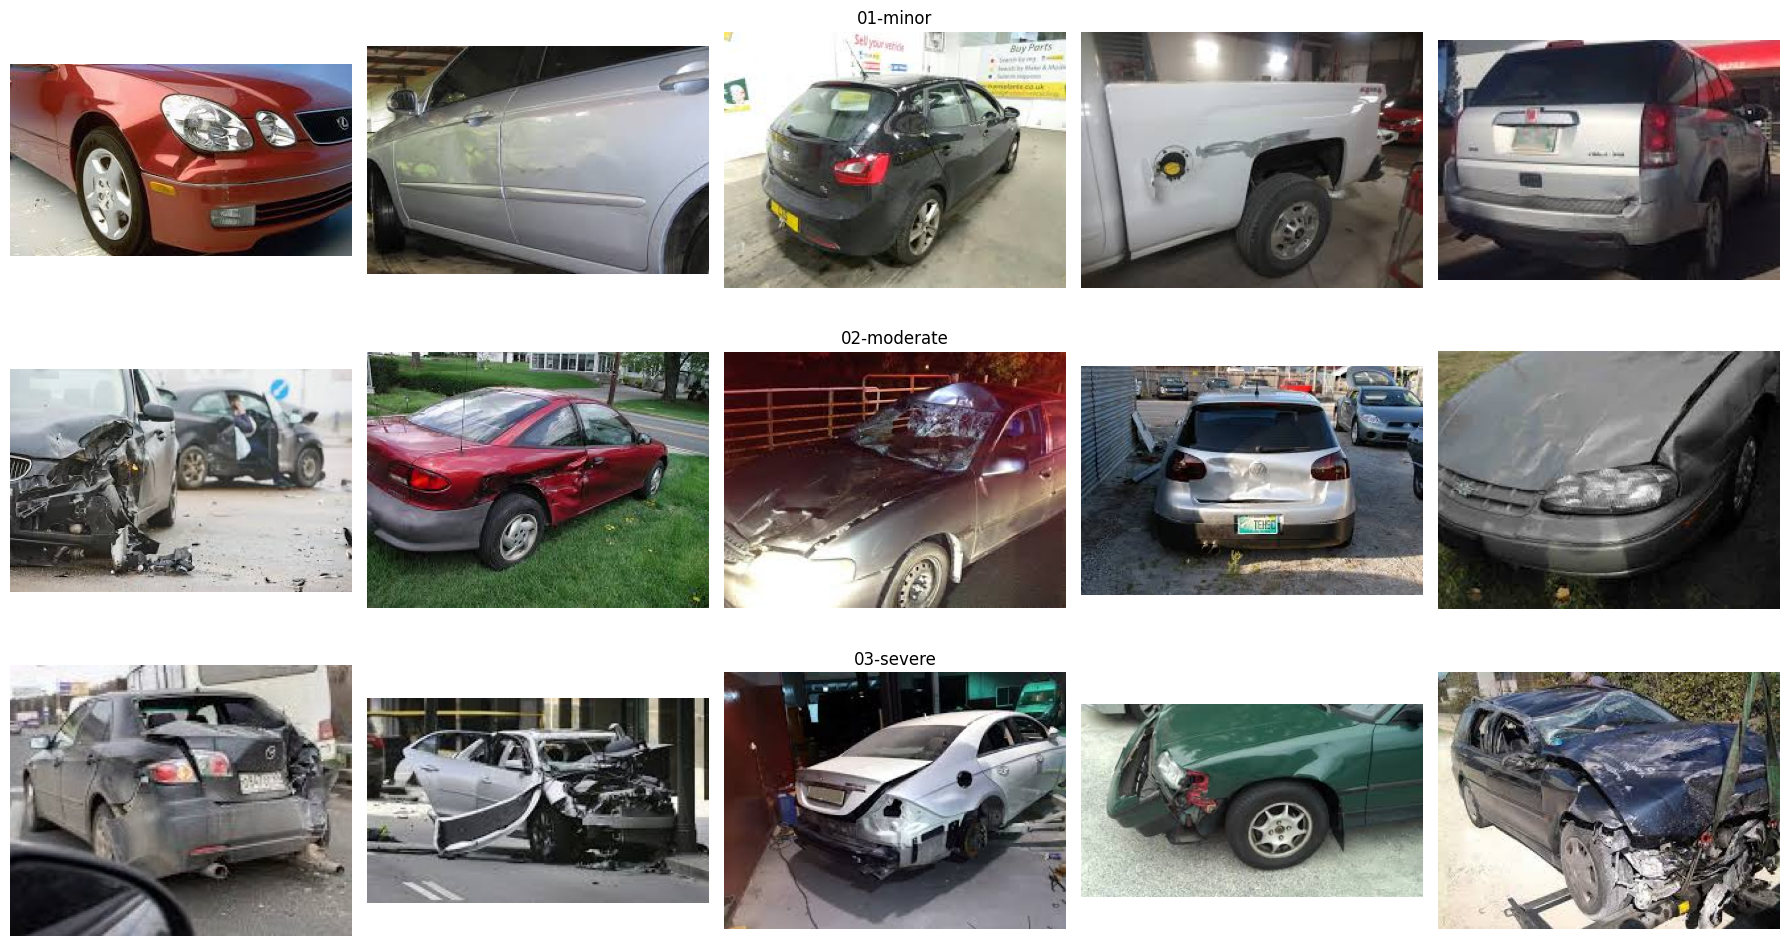

In [10]:
# ============================================
# Visualize Random Images from Each Class
# ============================================

classes = train_dataset.classes

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for class_idx, class_name in enumerate(classes):

    # Get image paths belonging to current class
    class_samples = [
        sample for sample in train_dataset.samples
        if sample[1] == class_idx
    ]

    # Select 5 random images
    selected_samples = random.sample(class_samples, 5)

    for j, (img_path, _) in enumerate(selected_samples):

        img = Image.open(img_path).convert("RGB")

        axes[class_idx, j].imshow(img)
        axes[class_idx, j].axis("off")

        if j == 2:
            axes[class_idx, j].set_title(class_name, fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
widths = []
heights = []
aspect_ratios = []

for img_path, _ in train_dataset.samples:

  img = Image.open(img_path)

  w, h = img.size

  widths.append(w)
  heights.append(h)
  aspect_ratios.append(round(w / h , 2))

print("=" * 50)
print("IMAGE RESOLUTION STATISTICS")
print("=" * 50)

print(f"Minimum Width  : {min(widths)}")
print(f"Maximum Width  : {max(widths)}")
print(f"Average Width  : {np.mean(widths):.2f}")

print()

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")
print(f"Average Height : {np.mean(heights):.2f}")

print()

print(f"Average Aspect Ratio : {np.mean(aspect_ratios):.2f}")


IMAGE RESOLUTION STATISTICS
Minimum Width  : 96
Maximum Width  : 411
Average Width  : 246.67

Minimum Height : 72
Maximum Height : 306
Average Height : 178.15

Average Aspect Ratio : 1.41


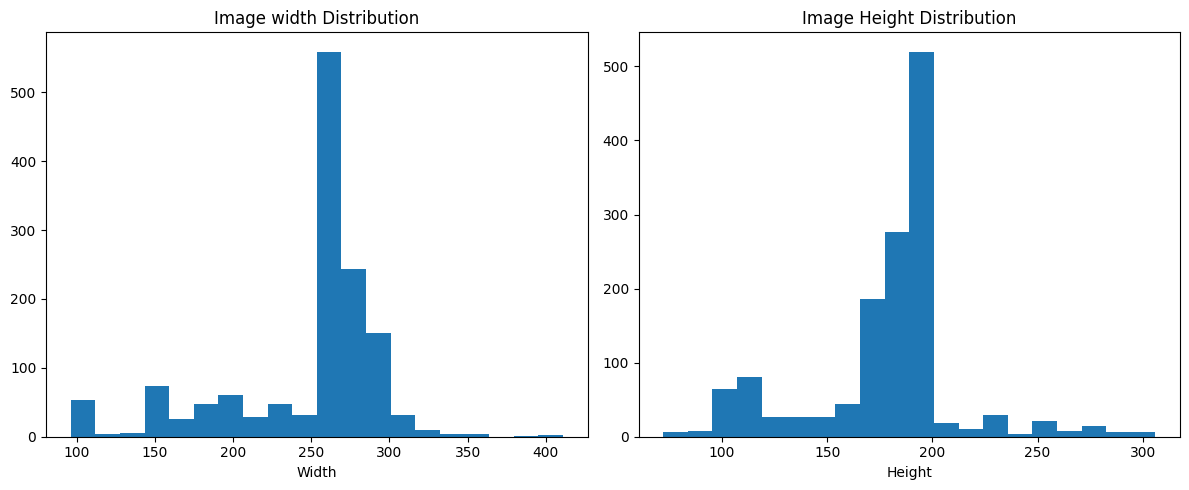

In [12]:
# ============================================
# Image Size Distribution
# ============================================

plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins = 20)
plt.title("Image width Distribution")
plt.xlabel("Width")

plt.subplot(1,2,2)
plt.hist(heights, bins = 20)
plt.title("Image Height Distribution")
plt.xlabel("Height")

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# Image Transformations
# ============================================

from torchvision import transforms

# ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.9,1.0)
    ),


    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])


In [14]:
# ============================
# Reload Dataset with Transforms
# ============================

train_dataset = datasets.ImageFolder(
    root = TRAIN_DIR,
    transform = train_transform
)

val_dataset = datasets.ImageFolder(
    root = VAL_DIR,
    transform = val_transform
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))

Training Images : 1383
Validation Images : 248


In [15]:
from collections import Counter

counts = Counter(label for _, label in train_dataset.samples)

for cls, idx in train_dataset.class_to_idx.items():
    print(cls, counts[idx])

01-minor 452
02-moderate 463
03-severe 468


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))


Train batches : 44
Validation batches : 8


In [17]:
# ============================================
# Verify DataLoader
# ============================================


images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Shape       :", labels.shape)

print("Image Data Type   :", images.dtype)
print("Label Data Type   :", labels.dtype)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])
Image Data Type   : torch.float32
Label Data Type   : torch.int64


In [18]:
# ============================================
# Load Pretrained ResNet18
# ============================================

from torchvision.models import (
    vit_b_16,
    ViT_B_16_Weights
)

weights = ViT_B_16_Weights.DEFAULT

model = vit_b_16(weights = weights)

print(model)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 184MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [19]:
in_features = model.heads[0].in_features
model.heads = nn.Sequential(
    nn.Linear(in_features,64),
    nn.ReLU(inplace = True),
    nn.Dropout(0.4),

    nn.Linear(64,32),
    nn.ReLU(inplace = True),
    nn.Dropout(0.3),

    nn.Linear(32, NUM_CLASSES)
)

model = model.to(DEVICE)

In [20]:
# Freeze feature extractor
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
  param.requires_grad = True

In [21]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Frozen Parameters     : {total_params-trainable_params:,}")

Total Parameters      : 85,850,051
Trainable Parameters  : 51,395
Frozen Parameters     : 85,798,656


In [22]:
import torch.optim as optim

#Loss Function
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-4
)

In [23]:
best_val_loss = float('inf')
patience = 15
counter = 0

In [24]:

for epoch in range(epochs):
  model.train()
  train_loss = 0

  for images,labels in train_loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    outputs = model(images)
    loss = criterion(outputs,labels)

    loss.backward()
    optimizer.step()

    optimizer.zero_grad()

    train_loss += loss.item()

  avg_train_loss = train_loss/len(train_loader)

  with torch.no_grad():
    model.eval()
    val_loss = 0

    for images,labels in val_loader:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      outputs = model(images)
      loss = criterion(outputs,labels)

      val_loss += loss.item()

  avg_val_loss = val_loss/len(val_loader)

  print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.6f} "
          f"Val Loss: {avg_val_loss:.6f}")

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    counter = 0
    torch.save(model.state_dict(), "best_model.pth")
  else:
    counter += 1
    if counter >= patience:
      print("Early Stopping Trigerred")
      break

Epoch [1/50] Train Loss: 1.091705 Val Loss: 1.070456
Epoch [2/50] Train Loss: 1.060140 Val Loss: 1.022864
Epoch [3/50] Train Loss: 1.016794 Val Loss: 0.951384
Epoch [4/50] Train Loss: 0.975838 Val Loss: 0.876088
Epoch [5/50] Train Loss: 0.923511 Val Loss: 0.816776
Epoch [6/50] Train Loss: 0.893025 Val Loss: 0.768273
Epoch [7/50] Train Loss: 0.862139 Val Loss: 0.734675
Epoch [8/50] Train Loss: 0.823940 Val Loss: 0.703642
Epoch [9/50] Train Loss: 0.819365 Val Loss: 0.683689
Epoch [10/50] Train Loss: 0.783619 Val Loss: 0.666349
Epoch [11/50] Train Loss: 0.776110 Val Loss: 0.655377
Epoch [12/50] Train Loss: 0.763993 Val Loss: 0.638102
Epoch [13/50] Train Loss: 0.755939 Val Loss: 0.632420
Epoch [14/50] Train Loss: 0.719164 Val Loss: 0.618159
Epoch [15/50] Train Loss: 0.714467 Val Loss: 0.617398
Epoch [16/50] Train Loss: 0.704642 Val Loss: 0.609122
Epoch [17/50] Train Loss: 0.694726 Val Loss: 0.613419
Epoch [18/50] Train Loss: 0.690207 Val Loss: 0.597867
Epoch [19/50] Train Loss: 0.671949 Va

In [25]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [26]:
# ============================================
# Prediction on Validation Dataset
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [27]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy : {accuracy*100:.2f}%")

Validation Accuracy : 72.98%


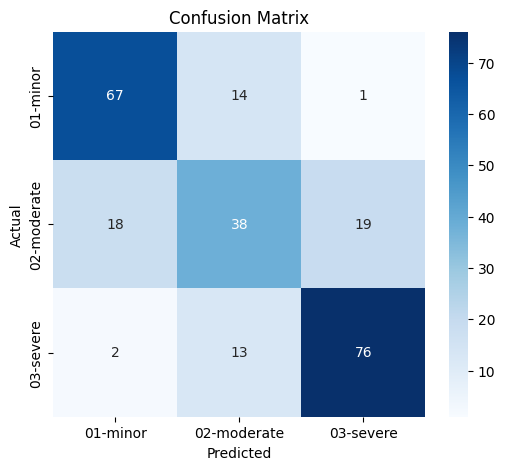

In [28]:
# ============================================
# Confusion Matrix
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [29]:
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

    01-minor       0.77      0.82      0.79        82
 02-moderate       0.58      0.51      0.54        75
   03-severe       0.79      0.84      0.81        91

    accuracy                           0.73       248
   macro avg       0.72      0.72      0.72       248
weighted avg       0.72      0.73      0.72       248

